Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

[OPTIMIZER] epoch_start=0 global_step=0 wrapped=AcceleratedOptimizer base=AdamW lr=0.0 id=137351093013296 hyperparams={'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 2e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 2e-05}
[SCHEDULER]   scheduler_last_lr=[0.0]
[PARAMS]   params_total=177,855,747 params_trainable=177,855,747


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro,Mse,Sse
1,0.413100,0.324824,0.876667,0.877917,0.893380,0.876667,0.061015,18.304484
2,0.238300,0.339524,0.900000,0.898228,0.901124,0.900000,0.052824,15.847060
3,0.141500,0.256189,0.936667,0.936559,0.938741,0.936667,0.037496,11.248673
4,0.080800,0.251258,0.943333,0.943009,0.943549,0.943333,0.033147,9.944217


[TRAINING_PERFORMANCE] epoch=1.0 tokens=0 time=27.15s tok/s=0.0 ex/s=0.00 peak_mem=3.34GiB lr=1.60e-05
[EVALUATION_PERFORMANCE] tokens=81920 time=0.16s tok/s=499929.4 ex/s=3905.70
[EVALUATION_PERFORMANCE] accuracy=0.8767 cost=$0.02 accuracy_per_$=55.82
[OPTIMIZER] epoch_start=1.0 global_step=150 wrapped=AcceleratedOptimizer base=AdamW lr=1.595744680851064e-05 id=137351093013296 hyperparams={'lr': 1.595744680851064e-05, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 2e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 1.595744680851064e-05, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 2e-05}
[SCHEDULER]   scheduler_last_lr=[1.595744680851064e-05]
[PARAMS]   p

[EVALUATION_PERFORMANCE] tokens=81920 time=0.34s tok/s=243816.8 ex/s=1904.82
[EVALUATION_PERFORMANCE] accuracy=0.9067 cost=$0.10 accuracy_per_$=8.67

### BERT-BASE-MULTILINGUAL-CASED EVALUATION METRICS ###
{'epoch': 4.0,
 'eval_accuracy': 0.9066666666666666,
 'eval_f1_macro': 0.9058955699540076,
 'eval_loss': 0.4163918197154999,
 'eval_mse': 0.05534047489851358,
 'eval_precision_macro': 0.9057016621081422,
 'eval_recall_macro': 0.9066666666666666,
 'eval_runtime': 0.4039,
 'eval_samples_per_second': 742.754,
 'eval_sse': 16.602142469554074,
 'eval_steps_per_second': 12.379}


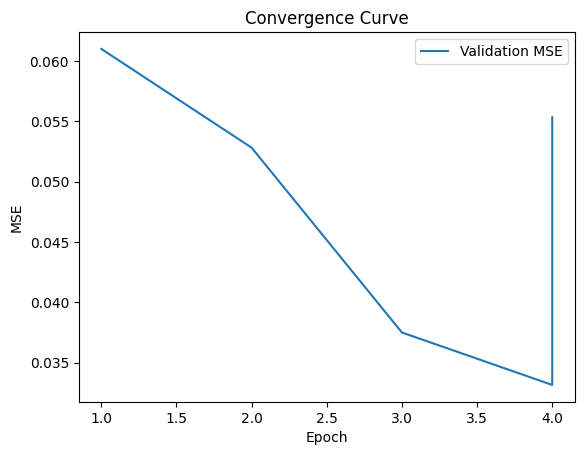

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2400 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

In [1]:
# A State Space Model Approach to Cross-Lingual Sentiment Analysis of Filipino Texts 


import os
import pandas as pd
import pprint

from pathlib import Path
from transformers import pipeline

from src.config import *
from src.metrics import evaluate_pipe
from src import (
    context,
    helper,
    sentiment, 
    utility, 
)

os.environ["HF_DATASETS_DISABLE_CACHING"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
helper.list_config()

if App.HAS_GPU:
    os.environ["MAMBA_USE_MAMBAPY"] = Mamba.FORCE_CUDA
    os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

if App.ACTION == "TRAIN":
    mbert_context = context.setup_pipeline(MBert, require_translation = False)
    mbert_trainer = sentiment.train(mbert_context)

